<a href="https://colab.research.google.com/github/COINtoolbox/crp8_segmentation/blob/main/Sagui_GPA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This code executes the Gradient Pattern Analysis (GPA) pipeline scripts from a .fits input image obtained by JWST. Adaptations may be required for application to images from other telescopes. The basic rescaling for applying GPA and visualizing the respective gradient field follows the M x N criterion, where the sizes of M and N are proportional to n x 16, where n is an integer. Here, approximately square stamps are rescaled to 32x32, and approximately rectangular stamps are rescaled to 48x32 or 32x48. This rescaling makes the gradient moment value invariant with the scale for comparative criteria. The greater the number of off-center bulges in the image, the higher the GA value.  By R.R.Rosa from COIN 2025.

# 1) Install Dependencies

In [ ]:
#@title 1.1) Install astropy
!pip -q install astropy

In [ ]:
#@title 1.2) Install GPA
!pip install git+https://github.com/rsautter/GPA

  Cloning https://github.com/rsautter/GPA to /tmp/pip-req-build-0jdqr36n
  Running command git clone --filter=blob:none --quiet https://github.com/rsautter/GPA /tmp/pip-req-build-0jdqr36n
  Resolved https://github.com/rsautter/GPA to commit 2c011bb317699305375b9847baf7a6f4509c0b4c
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [ ]:
#@title 2) Imports & parameters (edit these)

import io, os, zipfile, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from scipy import ndimage as ndi
from astropy.io import fits
from google.colab import files

# ==== Parameters you can tweak ====
PRIMARY_HDU = 0 # which HDU to read in the FITS file
K_SIGMA = 3.0 # threshold = median + K_SIGMA * sigma
MIN_AREA = 10 # min connected component area (pixels)
PAD_PIXELS = 6 # padding around each stamp bounding box
TOP_N_STAMPS = 5 # number of stamps to save
DOWNLOAD_ZIP = False # set True if you also want to download a zip of stamps
STAMP_RANK = 1 # (for gradient step) 1 = brightest detected source
# ================================

# Helpers (used by several cells)
def robust_stats(arr):
    med = np.median(arr)
    mad = np.median(np.abs(arr - med))
    sigma = 1.4826 * mad if mad > 0 else np.std(arr)
    return med, sigma

In [ ]:
#@title 3) Upload a FITS image from your computer

print("Upload your FITS file…")
uploaded = files.upload()
assert len(uploaded) >= 1, "No file uploaded."
fits_name = next(iter(uploaded.keys()))
print(f"Using: {fits_name}")

Upload your FITS file…


Saving reg1_F480M_aligned.fits to reg1_F480M_aligned.fits
Using: reg1_F480M_aligned.fits


# 4) loads a FITS image and displays it using a logarithmic color scale.

Steps:
- Loads the image data from a FITS file
- Replaces non-positive values with NaN to avoid issues with LogNorm
- Defines the minimum (`vmin`) and maximum (`vmax`) values for the color scale
- Uses `LogNorm` to apply a logarithmic stretch, which helps visualize both bright and faint features
- Plots the image using the 'inferno' colormap and adds a colorbar for reference

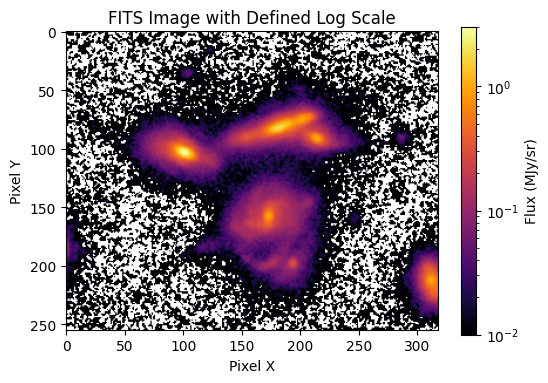

In [ ]:
from astropy.io import fits
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import numpy as np

fits_file = 'reg1_F480M_aligned.fits'
hdul = fits.open(fits_file)
image_data = hdul[0].data
hdul.close()

positive_image_data = np.where(image_data > 0, image_data, np.nan)

vmin = 1e-2
vmax = np.nanmax(image_data)

plt.figure(figsize=(6, 4))
plt.imshow(positive_image_data, cmap='inferno', norm=LogNorm(vmin=vmin, vmax=vmax))
plt.colorbar(label='Flux (MJy/sr)')
plt.title('FITS Image with Defined Log Scale')
plt.xlabel('Pixel X')
plt.ylabel('Pixel Y')
plt.show()

# 5) Removes the background from the image using sigma clipping, a technique that ignores very bright values (like stars) to estimate the background level (median) and noise (standard deviation).

Steps:
- Subtracts the estimated background from the image
- Removes negative values
- Creates a mask for pixels above 3 times the noise level
- Keeps only significant pixels (real sources)
- Displays the cleaned image with background removed and sources highlighted


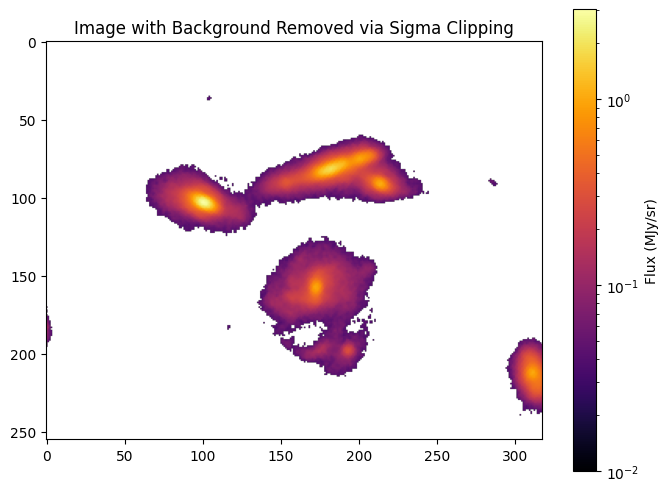

In [ ]:
from astropy.stats import sigma_clipped_stats

# Calculate statistics using sigma clipping
mean, median, std = sigma_clipped_stats(positive_image_data, sigma=3.0, maxiters=5)

# Subtract the median background
subtracted_image = positive_image_data - median
subtracted_image = np.where(subtracted_image > 0, subtracted_image, 0)

# Define threshold for significant signal
threshold = median + 3 * std
mask = subtracted_image > threshold

# Create a cleaned image with background removed
clean_image = np.where(mask, subtracted_image, 0)

# Display the cleaned imagea
plt.figure(figsize=(8, 6))
plt.imshow(clean_image, cmap='inferno', norm=LogNorm(vmin=vmin, vmax=vmax))
plt.colorbar(label='Flux (MJy/sr)')
plt.title('Image with Background Removed via Sigma Clipping')
plt.show()

hdul.close()

# 6) Based on previous physical properties (e.g. Redshift Information) segments and extracts the main regions (stamps) from a cleaned astronomical image.

Steps:  
- Define Physical Criteria for Scaling  the Cutting Area (in Pixels)
- Converts the cleaned image to a binary mask  
- Finds contours (boundaries) of connected regions  
- Filters regions with area greater than 1000 pixels  
- Creates masks for each large region and extracts them  
- Crops each region using bounding rectangles  
- Saves all large regions in a list for further use

In [ ]:
#@title 6.1) Obtain Amount of Stamps
from matplotlib.colors import LogNorm
import cv2

# Convert to uint8 for OpenCV (usually 0 or 255)
binary_mask = (clean_image > 0).astype(np.uint8) * 255

# Find contours of the regions (RETR_EXTERNAL mode to get only external contours)
contours, _ = cv2.findContours(binary_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

#Define cutting area scale L
L=1000

# List to store regions with area > L
large_regions = []

for contour in contours:
    area = cv2.contourArea(contour)
    if area > L:
        # Create a mask for the current region
        region_mask = np.zeros_like(binary_mask)
        cv2.drawContours(region_mask, [contour], -1, color=255, thickness=-1)  # filled

        # Apply the mask to the clean image to extract only this region
        region = cv2.bitwise_and(clean_image.astype(np.float32), clean_image.astype(np.float32), mask=region_mask)

        # Find bounding rectangle to crop
        x, y, w, h = cv2.boundingRect(contour)
        region_cropped = region[y:y+h, x:x+w]

        # Save the cropped image in the list
        large_regions.append(region_cropped)

print(f'Total large regions saved in the list: {len(large_regions)}')

Total large regions saved in the list: 2


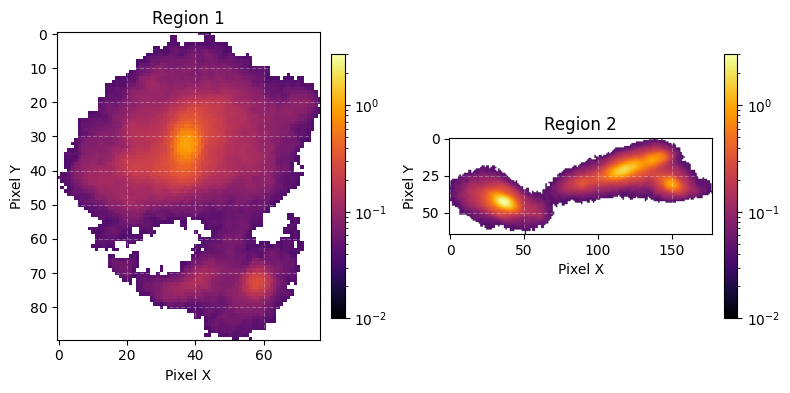

In [ ]:
#@title 6.2) Plot Stamps

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import numpy as np

n = len(large_regions)
cols = 2
rows = (n + cols - 1) // cols  # Calculate number of rows needed

fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))

axes = np.array(axes).reshape(-1)  # Flatten axes array for easy iteration

for i, ax in enumerate(axes):
    if i < n:
        img = large_regions[i]
        im = ax.imshow(img, cmap='inferno', norm=LogNorm(vmin=vmin, vmax=vmax))
        ax.set_title(f'Region {i+1}')

        # Mantém os eixos visíveis:
        ax.set_xlabel('Pixel X')
        ax.set_ylabel('Pixel Y')

        # Opcional: ativar grid para ajudar a visualizar os eixos
        ax.grid(True, color='white', alpha=0.3, linestyle='--')

        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    else:
        ax.axis('off')  # Turn off unused subplot axes

plt.tight_layout()
plt.show()

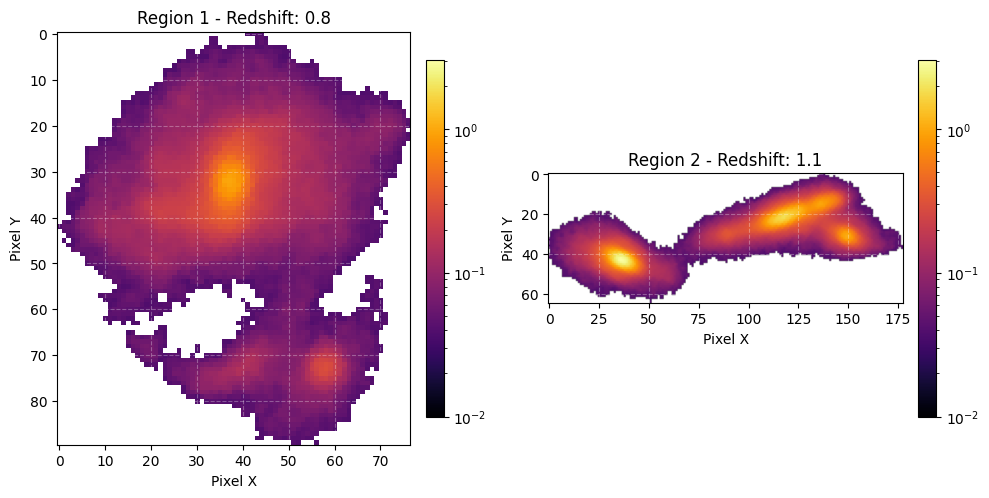

In [ ]:
#@title 6.3) Adding Redshift to Regions: the redshift is shown in the title of each image for easy identification.

redshifts = {
    0: 0.8,
    1: 1.1
}

n = len(large_regions)
cols = 2
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 5 * rows))
axes = np.array(axes).reshape(-1)

for i, ax in enumerate(axes):
    if i < n:
        img = large_regions[i]
        img_nonzero = img[img > 0]

        im = ax.imshow(img, cmap='inferno', norm=LogNorm(vmin=vmin, vmax=vmax))

        redshift = redshifts.get(i, 'sem tag')
        ax.set_title(f'Region {i+1} - Redshift: {redshift}')

        ax.set_xlabel('Pixel X')
        ax.set_ylabel('Pixel Y')
        ax.grid(True, color='white', alpha=0.3, linestyle='--')

        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    else:
        ax.axis('off')

plt.tight_layout()
plt.show()


# 7) Resizing the Segmented Regions for Gradient Pattern Analysis

Resizes each segmented region to a fixed height of 32 pixels while keeping the original width-to-height ratio.

- A 10-pixel margin is added around each region before resizing to avoid cropping.
- Resizing uses anti-aliasing interpolation to maintain image quality.
- The resized regions are displayed with a logarithmic scale and colorbar for better visualization.

This standardizes the region sizes for GPA application.



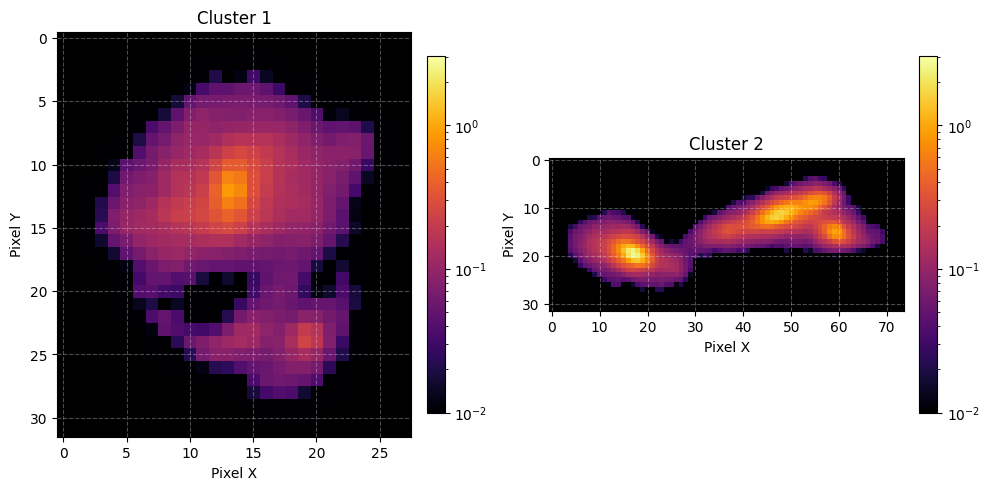

In [ ]:
from skimage.transform import resize
num_clusters = len(large_regions)

new_height = 32 #this the typical resize scale for the images from JWST be analysed with GPA
resized_large_regions = []

for crop in large_regions:
    # Add a 10-pixel margin (zero-padding) - Keep this for now, might be needed for aspect ratio
    crop_with_margin = np.pad(crop, pad_width=10, mode='constant', constant_values=0)

    original_height, original_width = crop_with_margin.shape

    # Calculate new width keeping the aspect ratio
    new_width = int(original_width * (new_height / original_height))

    # Resize image
    resized_crop = resize(crop_with_margin, (new_height, new_width), anti_aliasing=True)

    # Explicitly set values close to zero to zero to ensure a black background
    resized_crop[resized_crop < 1e-9] = 0 # Use a small threshold to account for floating point inaccuracies

    resized_large_regions.append(resized_crop)

# Display resized large regions (clusters) with logarithmic scale and colorbar
fig, axs = plt.subplots(1, num_clusters, figsize=(5 * num_clusters, 5))
if num_clusters == 1:
    axs = [axs]

for ax, crop, cluster_id in zip(axs, resized_large_regions, range(1, num_clusters + 1)):
    # Mask zero values for plotting with LogNorm
    masked_crop = np.ma.masked_where(crop <= 0, crop)

    im = ax.imshow(masked_crop, cmap='inferno', norm=LogNorm(vmin=vmin, vmax=vmax))
    ax.set_facecolor('black') # Set the background color of the axes to black
    ax.set_title(f'Cluster {cluster_id}')
    ax.set_xlabel('Pixel X')
    ax.set_ylabel('Pixel Y')
    ax.grid(True, color='white', alpha=0.3, linestyle='--')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

hdul.close()

# 8) Perfoming the Gradient Pattern Analysis

   Region        GA  Redshift
0       1  0.231402       0.8
1       2  0.433848       1.1


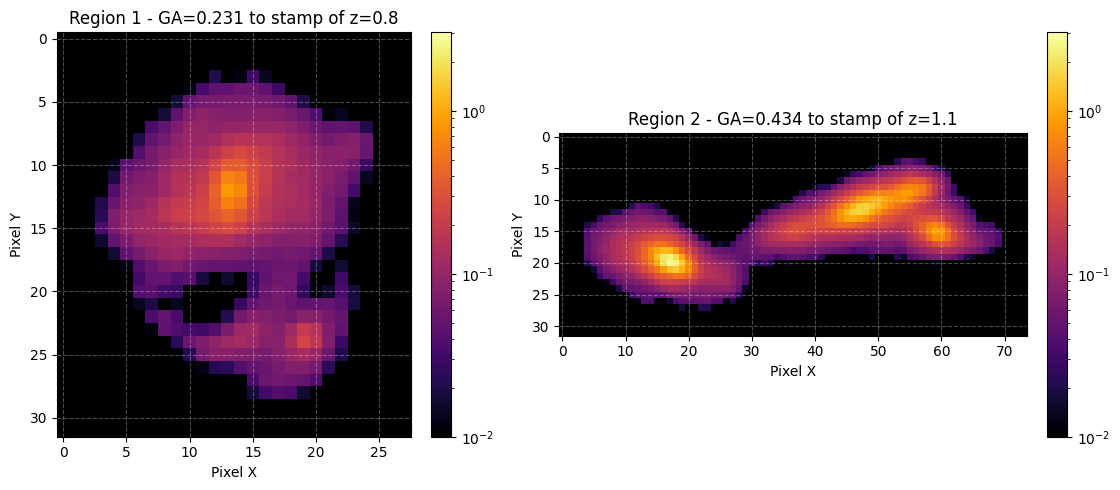

In [ ]:
import GPA
import pandas as pd

data = []

ga = GPA.GPA(0.08)  # Initialize GPA with some parameter

for i, crop in enumerate(resized_large_regions):
    crop_double = crop.astype(np.float64)

    moments_A = ga(crop_double, moment=['G3'], symmetrycalGrad='A')
    G3_value = moments_A.get('G3', np.nan)

    # Get corresponding redshift if available, else NaN
    z = redshifts[i] if i < len(redshifts) else np.nan

    data.append({'Region': i+1, 'GA': G3_value, 'Redshift': z, 'Image': crop})

# Create DataFrame
df = pd.DataFrame(data)

# Display table with Region, GA, and Redshift
print(df[['Region', 'GA', 'Redshift']])

# Plot all images in a 2-column grid
n = len(df)
cols = 2
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 5 * rows))
axes = axes.flatten()

# Turn off unused axes
for ax in axes[n:]:
    ax.axis('off')

for i, (ax, (_, row)) in enumerate(zip(axes[:n], df.iterrows())):
    img = row['Image']
    # Mask zero values for plotting with LogNorm
    masked_img = np.ma.masked_where(img <= 0, img)

    im = ax.imshow(masked_img, cmap='inferno', norm=LogNorm(vmin=vmin, vmax=vmax))
    ax.set_facecolor('black') # Set the background color of the axes to black
    ax.set_title(f"Region {row['Region']} - GA={row['GA']:.3f} to stamp of z={row['Redshift']}")
    ax.set_xlabel('Pixel X')
    ax.set_ylabel('Pixel Y')
    ax.grid(True, color='white', alpha=0.3, linestyle='--')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

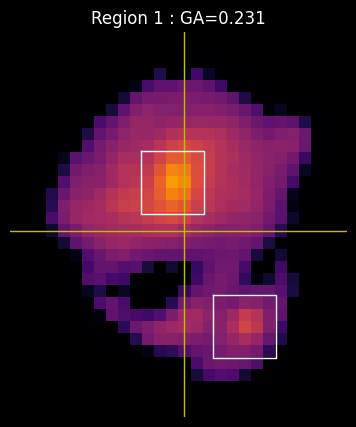

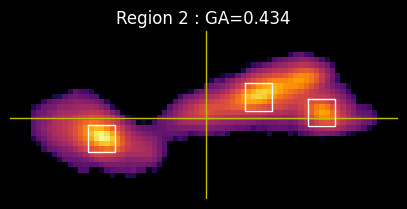

In [ ]:
#@title 8.1) Showing the mosaic with the respective asymmetric axis and sub-regions: The more off-center bulges (bright centers), the greater the bilateral asymmetry and therefore the greater the GA value.
from skimage.feature import peak_local_max
from skimage.segmentation import watershed
from skimage import measure

# Plot and save each image with squares around bright regions and central lines
for index, row in df.iterrows():
    plt.figure(figsize=(5, 5))
    img = row['Image']
    # Mask zero values for plotting with LogNorm
    masked_img = np.ma.masked_where(img <= 0, img)

    im = plt.imshow(masked_img, cmap='inferno', norm=LogNorm(vmin=vmin, vmax=vmax))
    ax = plt.gca() # Get the current axes
    ax.set_facecolor('black') # Set the background color of the axes to black
    plt.gcf().patch.set_facecolor('black') # Set the background color of the figure


    # Add central horizontal and vertical lines
    height, width = img.shape
    center_x, center_y = width // 2, height // 2
    plt.axhline(y=center_y, color='y', linestyle='-', linewidth=1)
    plt.axvline(x=center_x, color='y', linestyle='-', linewidth=1)

    # Find local maxima (brightest points)
    # Adjust min_distance and threshold_abs as needed based on your image data
    # Decreased min_distance and adjusted threshold to capture more peaks
    coordinates = peak_local_max(img, min_distance=5, threshold_abs=np.percentile(img[img > 0], 85))


    # Draw a square around each local maximum
    square_size = 2.6  # Adjust size as needed
    for coords in coordinates:
        max_y, max_x = coords
        plt.plot([max_x - square_size, max_x + square_size, max_x + square_size, max_x - square_size, max_x - square_size],
                 [max_y - square_size, max_y - square_size, max_y + square_size, max_y + square_size, max_y - square_size],
                 color='white', linewidth=1) # Use white for visibility


    plt.axis('off') # Turn off axes
    plt.grid(False) # Turn off grid

    # Add GA value to the title and set title color to white
    plt.title(f"Region {row['Region']} : GA={row['GA']:.3f}", color='white')

    # Save the figure as a PNG file with black background
    filename = f"R{row['Region']}_highlighted_multiple.png" # Create a simplified filename
    plt.savefig(filename, bbox_inches='tight', pad_inches=0, facecolor='black') # Save the figure with black background
    plt.show() # Display the figure
    plt.close() # Close the figure to free up memory

In [ ]:
# Plot and save each image separately without grid and axes
for index, row in df.iterrows():
    plt.figure(figsize=(5, 5))
    im = plt.imshow(row['Image'], cmap='inferno', norm=LogNorm(vmin=vmin, vmax=vmax))
    # plt.title(f"Region {row['Region']} - GA={row['GA']:.3f} to stamp of z={row['Redshift']}") # Removed title
    # plt.colorbar(im, label='Flux (MJy/sr)') # Removed colorbar
    plt.axis('off') # Turn off axes
    plt.grid(False) # Turn off grid

    # Save the figure as a PNG file with black background
    filename = f"R{row['Region']}.png" # Create a simplified filename
    plt.savefig(filename, bbox_inches='tight', pad_inches=0, facecolor='black') # Save the figure with black background
    plt.close() # Close the figure to free up memory

In [ ]:
#@title 8.2) Showing the Gradient Lattice on the Image
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# abre o arquivo
image = Image.open("R1.png")
#mostra a imagem
#plt.figure(figsize=(4,4))
#plt.imshow(image,origin='lower')
#plt.colorbar()
#plt.show()

/tmp/ipython-input-3566594831.py:26: RuntimeWarning: invalid value encountered in divide
  dx,dy = dx/abs,dy/abs


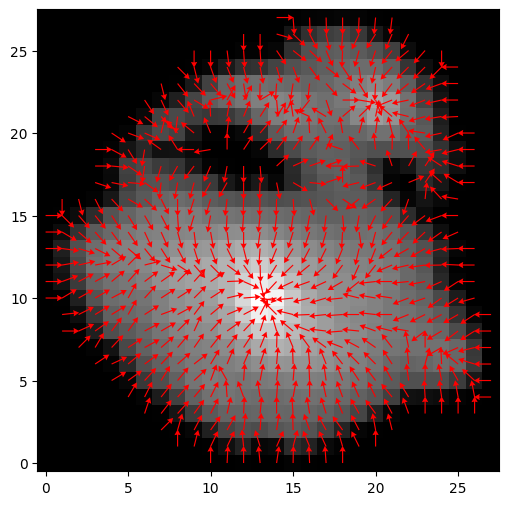

In [ ]:
from GPA import GPA

# converte para tons de cinza
image = image.convert('L')


#Scaling Resize nx16
# n=2 for R1 ; 2 x 16 32 ==> (32,32)
# n=3 for R2 ; 3x16 = 48 ==> (48,32)

image = image.resize((32,32))
#image = image.resize((48,32))


# normaliza pelo valor maximo
im = np.array(image).astype(float)[2:-2,2:-2]

# tol eh a tolerancia da tecnica
ga = GPA(tol = 0.05)
ga(im)
sym = np.array(ga.symmetricalP)
asym = np.array(ga.asymmetricalP)

dx, dy = np.gradient(im)
abs = (dx**2+dy**2)**0.5
dx,dy = dx/abs,dy/abs

#mostra a imagem
plt.figure(figsize=(6,6))
plt.imshow(im,cmap='gray',origin='lower')

#mostra a grade gradiente total
plt.quiver(dy,dx,color='r',scale=27,width=0.0025,headwidth=5.5)
#plt.legend(fontsize=8,loc=1)

plt.show()

/tmp/ipython-input-341908734.py:24: RuntimeWarning: invalid value encountered in divide
  dx,dy = dx/abs,dy/abs


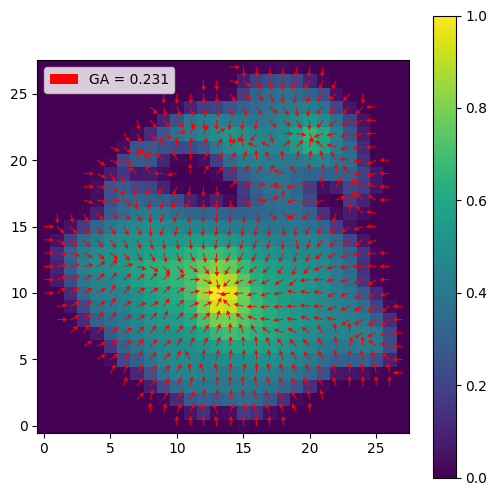

In [ ]:
from GPA import GPA

# converte para tons de cinza
image = image.convert('L')

#Scaling Resize nx16
# n=2 for R1 ; 2 x 16 32 ==> (32,32)
# n=3 for R2 ; 3x16 = 48 ==> (48,32)

image = image.resize((32,32))
#image = image.resize((48,32))

# normaliza pelo valor maximo
im = np.array(image).astype(float)[2:-2,2:-2]

# tol eh a tolerancia da tecnica
ga = GPA(tol = 0.05)
ga(im)
sym = np.array(ga.symmetricalP)
asym = np.array(ga.asymmetricalP)

dx, dy = np.gradient(im)
abs = (dx**2+dy**2)**0.5
dx,dy = dx/abs,dy/abs

ga = df[df['Region'] == 1]['GA'].iloc[0]

#mostra a imagem
plt.figure(figsize=(6,6))
#plt.imshow(im,cmap='gray',origin='lower')
plt.imshow(im,origin='lower')

#mostra a grade gradiente total
plt.quiver(dy,dx,color='r',scale=37,width=0.0025,headwidth=5.1,  label=f'GA = {ga:.3f}')
#plt.legend(fontsize=8,loc=1)
plt.colorbar()
plt.legend(fontsize=10, loc=2) # Added legend R1
#plt.legend(fontsize=10, loc=1) # Added legend R2
plt.show()

# Appendix - Understanding the G_A measure from canonical patterns of bilateral symmetry and asymmetry